In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest

import gymnasium as gym
import bbrl_gymnasium

from pmind.data.loader import load_all_buffers, load_all_policies

from pmind.algorithms import DQN, DDPG, TD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import run_dqn, run_ddpg, run_td3
from pmind.config.loader import load_config

from pmind.replay import mix_transitions

from pmind.config.environments import (
    ENV_NAMES,
    REWARDS_TO_PLOT,
    EPISODE_LENGTHS,
    show_plot_defaults,
)

from pmind.plot.policies import (
    plot_rb_space_coverage,
    plot_policy,
    plot_trajectories,
    plot_replay_buffers,
    plot_policies
)

bbrl_utils.setup()

%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

/Users/vlad/Documents/University/Master-MIND/projet-mind/.venv/lib/python3.10/site-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Using Python 3.10.18 environment at: /Users/vlad/Documents/University/Master-MIND/projet-mind/.venv


# Set up state-action space information

Is specific for each environment

In [2]:
ENVS_TO_PLOT = tuple(ENV_NAMES)
show_plot_defaults(ENVS_TO_PLOT)

CartPoleContinuous-v1
state variables ['position', 'velocity', 'angle', 'angular velocity']
bounded by:
 [[-4.8         4.8       ]
 [       -inf         inf]
 [-0.41887903  0.41887903]
 [-0.5         3.        ]]
initialized in:
 [[-0.05  0.05]
 [-0.05  0.05]
 [-0.05  0.05]
 [-0.05  0.05]]
Chosen for plot: position and angular velocity
using cartesian coordinates
Pendulum-v1
state variables ['cosine', 'sine', 'angular velocity']
bounded by:
 [[-1.  1.]
 [-1.  1.]
 [-8.  8.]]
initialized in:
 [[-1  1]
 [-1  1]
 [-1  1]]
Chosen for plot: angle and angular velocity
using polar coordinates
MountainCarContinuous-v0
state variables ['position', 'velocity']
bounded by:
 [[-1.2   0.6 ]
 [-0.07  0.07]]
initialized in:
 [[-0.6 -0.4]
 [ 0.   0. ]]
Chosen for plot: position and velocity
using cartesian coordinates


# Visualize replay buffers

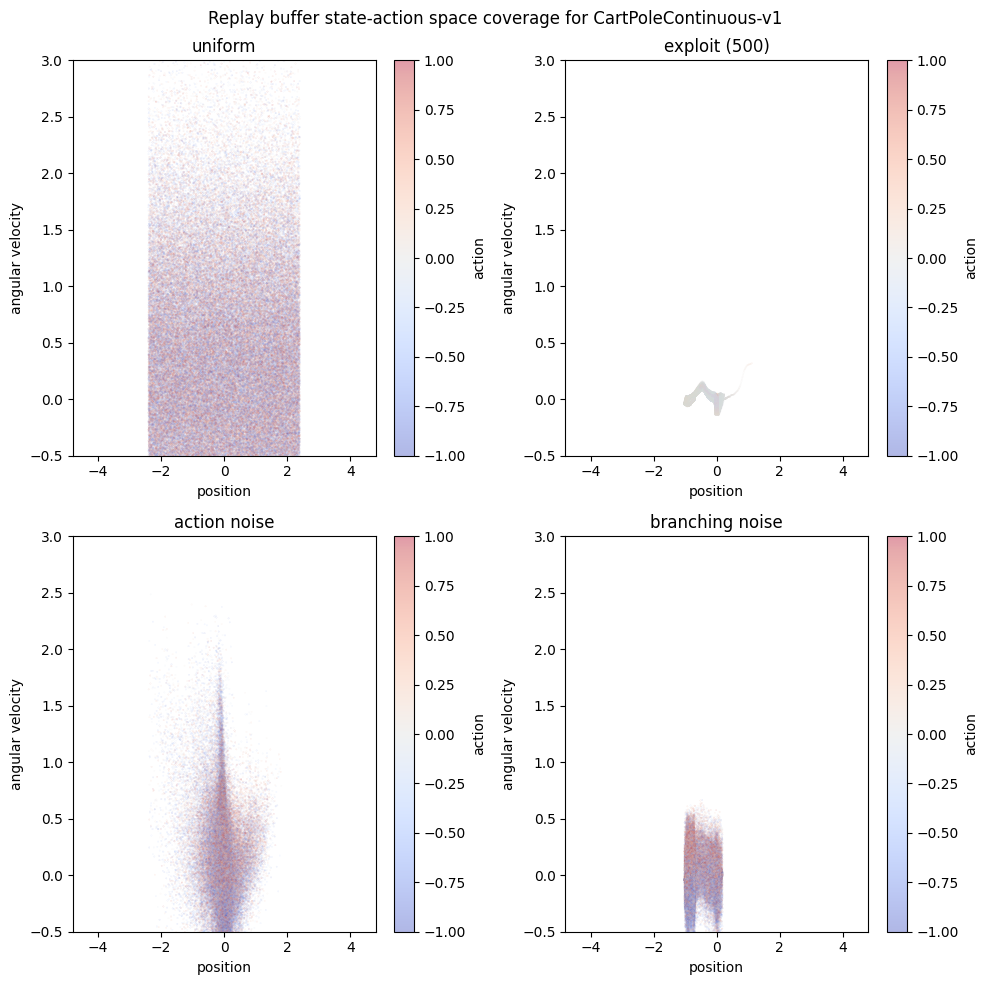

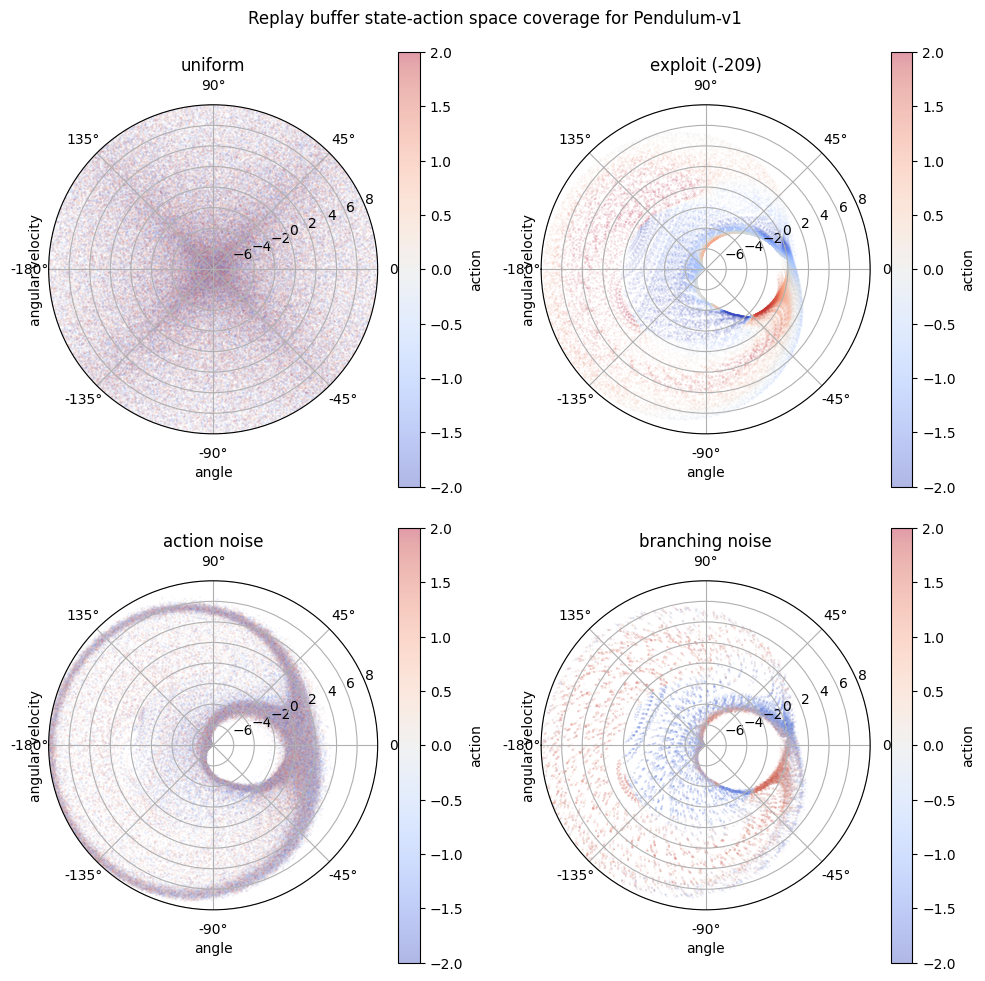

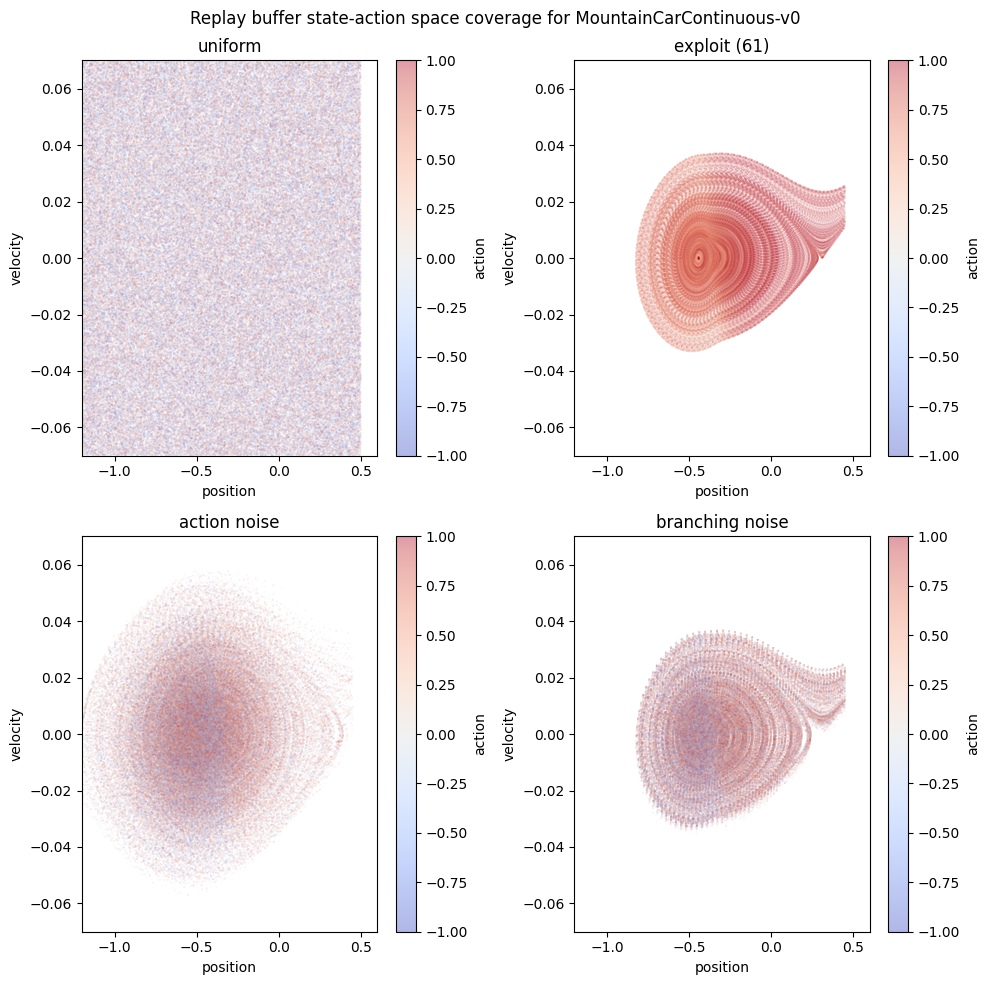

In [3]:
for env_name in ENVS_TO_PLOT:
    replay_buffers = load_all_buffers(env_name, for_plot=True)
    plot_replay_buffers(replay_buffers, env_name)
    plt.show()

# Visualize online-learned policies

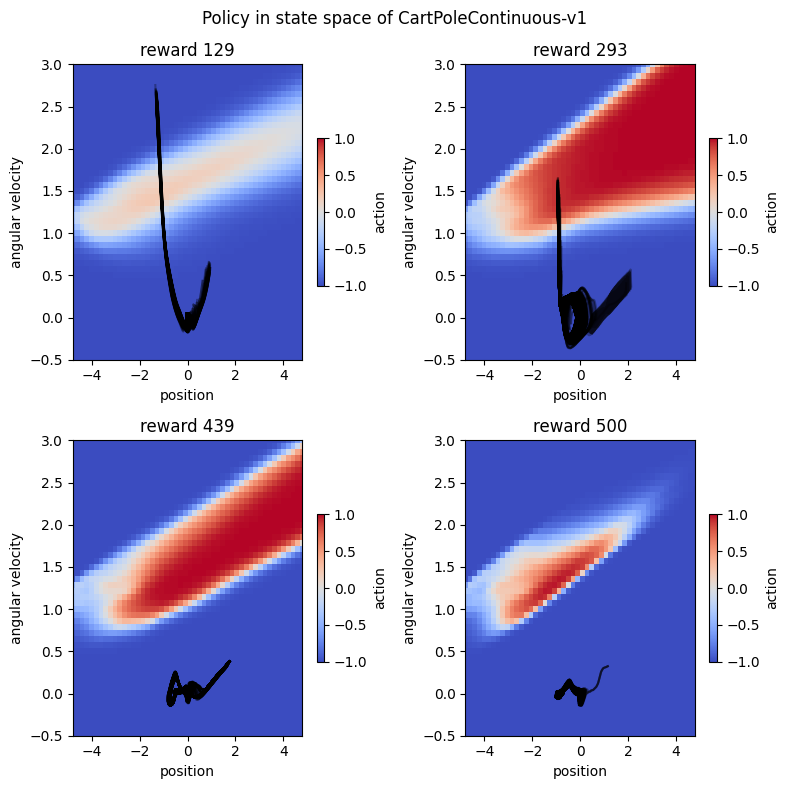

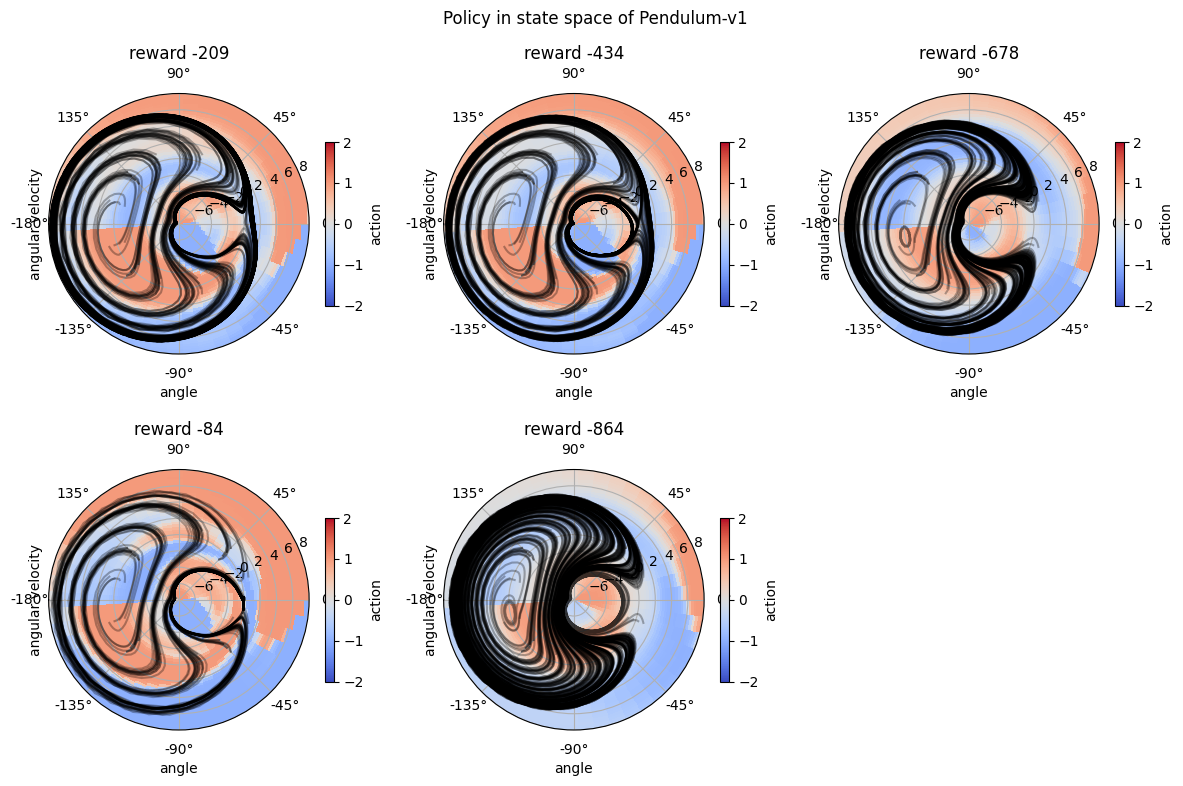

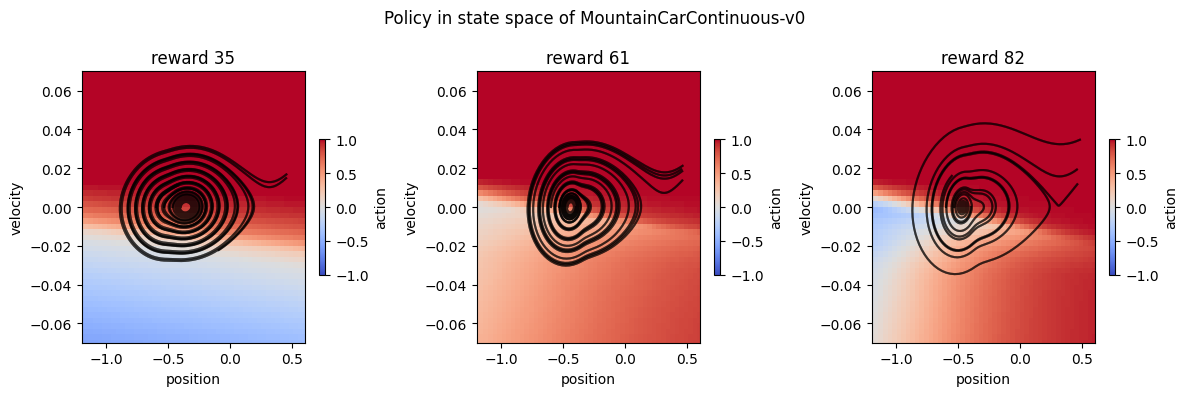

In [9]:
for env_name in ENVS_TO_PLOT:
    policies = load_all_policies(env_name, for_plot=False)
    plot_policies(policies, env_name, n_trajectories=4)
    plt.show()

# Visualize offline-learned policies

In [5]:
# # Obtain policies and replay buffers from offline learning experiments:
# RESULTS_DIR = "../results/policy_analysis-selected"
# rb_composition_type = ("uniform_proportions", "noise_levels")[0]
# reward = 500 #61
# FNAME = f"{rb_composition_type}-{ENV_NAME}-scoring-{reward}"
# test_log = torch.load(f"{RESULTS_DIR}/{FNAME}", weights_only=False)
# policies = test_log["policies"]
# replay_buffers = test_log["replay_buffers"]
# save_rb_policy_interval = test_log["save_rb_policy_interval"]
# rb_composition = test_log["rb_composition"]
# rb_composition_type = test_log["type"]

# rb = replay_buffers[0][0]
# policies_over_time = policies[0][0]

In [6]:
# fig, ax = plt.subplots(figsize=(7,7),subplot_kw={"projection": "polar"} if POLAR_COORD else None)
# plot_rb_space_coverage(ENV_NAME, rb, STATE_X, STATE_Y, ax=ax)
# fig.suptitle(
#     f"Replay buffer composition used for offline learning\n {rb_composition[0]}"
#     + (
#         " of uniform exploration"
#         if rb_composition_type == "uniform_proportions"
#         else " of action noise"
#     ) + f" with exploitation policy scoring {reward}"
# )
# plt.show()
# nrows = 3
# fig, axes = plt.subplots(nrows, len(policies_over_time) // nrows + 1, figsize=(10, 10),subplot_kw={"projection": "polar"} if POLAR_COORD else None)
# axes = axes.flatten()
# for i, policy in enumerate(policies_over_time):
#     plot_policy(ENV_NAME, policy, STATE_X, STATE_Y, ax=axes[i])
#     plot_trajectories(ENV_NAME, policy, NB_TRAJ, STATE_X, STATE_Y, ax=axes[i])
#     axes[i].set_title(f"{(i + 1) * save_rb_policy_interval} steps")
# for ax in axes[i + 1 :]:
#     fig.delaxes(ax)
# fig.suptitle("Policy evolution during offline learning")
# plt.show()

# SANDBOX

# Visualize learned Q-values

## TODO: get critic as well, not only actor

In [7]:
# for ENV_NAME in ENV_NAMES:
#     ENV = gym.make(ENV_NAME)
#     STATE_SPACE = np.array([ENV.observation_space.low, ENV.observation_space.high]).T
#     print({ENV_NAME: STATE_SPACE})